In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [4]:
ne_lpn_model_config_path = os.path.join('..','models','ne_lpn','s=0.1','model_config.json')
ne_lpn_model_weight_path = os.path.join('..','models','ne_lpn','s=0.1','model.pt')
ne_lpn_model_config = load_config(ne_lpn_model_config_path)
ne_lpn_model = get_model(ne_lpn_model_config)
ne_lpn_model.load_state_dict(torch.load(ne_lpn_model_weight_path)['model_state_dict'])
ne_lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [5]:
ne_lpn_by_forward_model_config_path = '../models/ne_by_forward_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forward_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [6]:
ne_lpn_normalized_and_scaled_model_config_path = '../models/ne_norm_and_scaled_lpn/s=0.1/model_config.json'
ne_lpn_normalized_and_scaled_model_weight_path = '../models/ne_norm_and_scaled_lpn/s=0.1/model.pt'
ne_lpn_normalized_and_scaled_model_config = load_config(ne_lpn_normalized_and_scaled_model_config_path)
ne_lpn_normalized_and_scaled_model = get_model(ne_lpn_normalized_and_scaled_model_config)
ne_lpn_normalized_and_scaled_model.load_state_dict(torch.load(ne_lpn_normalized_and_scaled_model_weight_path)['model_state_dict'])
ne_lpn_normalized_and_scaled_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [7]:
drunet_model_config_path = '../models/drunet/s=0.1/model_config.json'
drunet_model_weight_path = '../models/drunet/s=0.1/model.pt'
drunet_model_config = load_config(drunet_model_config_path)
drunet_model = get_model(drunet_model_config)
drunet_model.load_state_dict(torch.load(drunet_model_weight_path)['model_state_dict'])
drunet_model.to(device)

DRUNet(
  (m_head): AffineConv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, 

In [8]:
drunet_mini_model_config_path = '../models/drunet_mini/s=0.1/model_config.json'
drunet_mini_model_weight_path = '../models/drunet_mini/s=0.1/model.pt'
drunet_mini_model_config = load_config(drunet_mini_model_config_path)
drunet_mini_model = get_model(drunet_mini_model_config)
drunet_mini_model.load_state_dict(torch.load(drunet_mini_model_weight_path)['model_state_dict'])
drunet_mini_model.to(device)

DRUNet(
  (m_head): AffineConv2d(3, 34, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(34, 34, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(34, 34, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(34, 34, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(34, 34, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(34, 34, 

In [9]:
less_drunet_mini_model_config_path = '../models/less_drunet_mini/s=0.1/model_config.json'
less_drunet_mini_model_weight_path = '../models/less_drunet_mini/s=0.1/model.pt'
less_drunet_mini_model_config = load_config(less_drunet_mini_model_config_path)
less_drunet_mini_model = get_model(less_drunet_mini_model_config)
less_drunet_mini_model.load_state_dict(torch.load(less_drunet_mini_model_weight_path)['model_state_dict'])
less_drunet_mini_model.to(device)

DRUNet(
  (m_head): AffineConv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, 

In [10]:
ne_lpn_64ch_model_config_path = '../models/backup_temp/ne_lpn_64ch_s=0.1/model_config.json'
ne_lpn_64ch_model_weight_path = '../models/backup_temp/ne_lpn_64ch_s=0.1/model.pt'
ne_lpn_64ch_model_config = load_config(ne_lpn_64ch_model_config_path)
ne_lpn_64ch_model = get_model(ne_lpn_64ch_model_config)
ne_lpn_64ch_model.load_state_dict(torch.load(ne_lpn_64ch_model_weight_path)['model_state_dict'])
ne_lpn_64ch_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(64, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 64, kernel_size=(3

In [11]:
ordinary_drunet_config_path = '../models/ordinary_drunet/s=0.1/model_config.json'
ordinary_drunet_weight_path = '../models/ordinary_drunet/s=0.1/model.pt'
ordinary_drunet_config = load_config(ordinary_drunet_config_path)
ordinary_drunet_model = get_model(ordinary_drunet_config)
ordinary_drunet_model.load_state_dict(torch.load(ordinary_drunet_weight_path)['model_state_dict'])
ordinary_drunet_model.to(device)

DRUNet(
  (m_head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (sum):

In [12]:
ne_lpn_norm_and_scaled_wbias = '../models/ne_norm_and_scaled_wbias_lpn/s=0.1/model.pt'
ne_lpn_norm_and_scaled_wbias_config_path = '../models/ne_norm_and_scaled_wbias_lpn/s=0.1/model_config.json'
ne_lpn_norm_and_scaled_wbias_config = load_config(ne_lpn_norm_and_scaled_wbias_config_path)
ne_lpn_norm_and_scaled_wbias_model = get_model(ne_lpn_norm_and_scaled_wbias_config)
ne_lpn_norm_and_scaled_wbias_model.load_state_dict(torch.load(ne_lpn_norm_and_scaled_wbias)['model_state_dict'])
ne_lpn_norm_and_scaled_wbias_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [13]:
modified_drunet_config_path = '../models/modified_drunet/s=0.1/model_config.json'
modified_drunet_weight_path = '../models/modified_drunet/s=0.1/model.pt'
modified_drunet_config = load_config(modified_drunet_config_path)
modified_drunet_model = get_model(modified_drunet_config)
modified_drunet_model.load_state_dict(torch.load(modified_drunet_weight_path)['model_state_dict'])
modified_drunet_model.to(device)


ModifiedDRUNet(
  (m_head): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): SortPool()
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): SortPool()
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): SortPool()
          (2): Conv2d(64, 64, kernel_size=(3, 3),

In [14]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [15]:
def visualize_dataloader(dataloader):
    for i, data in enumerate(dataloader):
        image = data['image'].squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.imshow(image)
        plt.show()
        if i == 5:
            break
#visualize_dataloader(test_dataloader)  #uncomment to visualize

In [16]:
noise_levels = [0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7]

In [17]:
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim

def evaluate_model(model, dataloader, noise_levels):
    model.eval()
    avg_psnr_list = []
    avg_ssim_list = []

    for noise in tqdm(noise_levels, total=len(noise_levels)):
        psnr_list = []
        ssim_list = []
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            img = data['image'].to(device)
            noise_tensor = torch.randn_like(img) * noise
            noisy_img = img + noise_tensor

            with torch.no_grad():
                denoised_img = model(noisy_img)

            img_np = img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy() 
            denoised_np = denoised_img.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

            psnr = skimage_psnr(img_np, denoised_np, data_range=1.0)
            ssim = skimage_ssim(img_np, denoised_np, data_range=1.0, channel_axis=-1)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
        avg_psnr = np.mean(psnr_list)
        avg_ssim = np.mean(ssim_list)
        avg_psnr_list.append(avg_psnr)
        avg_ssim_list.append(avg_ssim)
        print(f"Average PSNR for noise level {noise}: {avg_psnr:.2f}")
        print(f"Average SSIM for noise level {noise}: {avg_ssim:.4f}")
    return avg_psnr_list, avg_ssim_list


In [18]:
lpn_psnr, lpn_ssim = evaluate_model(lpn_model, test_dataloader, noise_levels)

  0%|          | 0/8 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:25<02:57, 25.41s/it]

Average PSNR for noise level 0.05: 31.20
Average SSIM for noise level 0.05: 0.8824


 25%|██▌       | 2/8 [00:28<01:15, 12.57s/it]

Average PSNR for noise level 0.1: 29.55
Average SSIM for noise level 0.1: 0.8600


...

Average PSNR for noise level 0.5: 5.26
Average SSIM for noise level 0.5: 0.0826


 88%|████████▊ | 7/8 [00:45<00:04,  4.09s/it]

Average PSNR for noise level 0.6: 1.56
Average SSIM for noise level 0.6: 0.0409


100%|██████████| 8/8 [00:48<00:00,  6.10s/it]

Average PSNR for noise level 0.7: -1.38
Average SSIM for noise level 0.7: 0.0187


In [19]:
ne_lpn_psnr, ne_lpn_ssim = evaluate_model(ne_lpn_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:34,  4.87s/it]

Average PSNR for noise level 0.05: 23.57
Average SSIM for noise level 0.05: 0.7631


 25%|██▌       | 2/8 [00:09<00:26,  4.46s/it]

Average PSNR for noise level 0.1: 23.31
Average SSIM for noise level 0.1: 0.7127


 38%|███▊      | 3/8 [00:12<00:20,  4.04s/it]

...

Average PSNR for noise level 0.5: 16.44
Average SSIM for noise level 0.5: 0.2959


 88%|████████▊ | 7/8 [00:27<00:03,  3.80s/it]

Average PSNR for noise level 0.6: 15.04
Average SSIM for noise level 0.6: 0.2441


100%|██████████| 8/8 [00:31<00:00,  3.94s/it]

Average PSNR for noise level 0.7: 13.82
Average SSIM for noise level 0.7: 0.2055


In [20]:
ne_lpn_64ch_psnr, ne_lpn_64ch_ssim = evaluate_model(ne_lpn_64ch_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:31,  4.45s/it]

Average PSNR for noise level 0.05: 23.12
Average SSIM for noise level 0.05: 0.7628


 25%|██▌       | 2/8 [00:08<00:23,  3.97s/it]

Average PSNR for noise level 0.1: 22.82
Average SSIM for noise level 0.1: 0.7250


 38%|███▊      | 3/8 [00:11<00:18,  3.72s/it]

...

Average PSNR for noise level 0.5: 16.40
Average SSIM for noise level 0.5: 0.3034


 88%|████████▊ | 7/8 [00:25<00:03,  3.62s/it]

Average PSNR for noise level 0.6: 15.05
Average SSIM for noise level 0.6: 0.2501


100%|██████████| 8/8 [00:28<00:00,  3.52s/it]

Average PSNR for noise level 0.7: 13.87
Average SSIM for noise level 0.7: 0.2100


In [21]:
ne_by_forward_psnr, ne_by_forward_ssim = evaluate_model(ne_lpn_by_forward_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:22,  3.21s/it]

Average PSNR for noise level 0.05: 31.03
Average SSIM for noise level 0.05: 0.8857


 25%|██▌       | 2/8 [00:06<00:19,  3.23s/it]

Average PSNR for noise level 0.1: 29.10
Average SSIM for noise level 0.1: 0.8441


 38%|███▊      | 3/8 [00:09<00:16,  3.26s/it]

...

Average PSNR for noise level 0.5: 17.25
Average SSIM for noise level 0.5: 0.3350


 88%|████████▊ | 7/8 [00:22<00:03,  3.23s/it]

Average PSNR for noise level 0.6: 15.77
Average SSIM for noise level 0.6: 0.2783


100%|██████████| 8/8 [00:25<00:00,  3.24s/it]

Average PSNR for noise level 0.7: 14.52
Average SSIM for noise level 0.7: 0.2341


In [22]:
ne_norm_and_scaled_psnr, ne_norm_and_scaled_ssim = evaluate_model(ne_lpn_normalized_and_scaled_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:26,  3.82s/it]

Average PSNR for noise level 0.05: 23.78
Average SSIM for noise level 0.05: 0.7726


 25%|██▌       | 2/8 [00:07<00:21,  3.59s/it]

Average PSNR for noise level 0.1: 23.49
Average SSIM for noise level 0.1: 0.7232


 38%|███▊      | 3/8 [00:11<00:18,  3.78s/it]

...

Average PSNR for noise level 0.5: 16.62
Average SSIM for noise level 0.5: 0.3002


 88%|████████▊ | 7/8 [00:26<00:03,  3.79s/it]

Average PSNR for noise level 0.6: 15.24
Average SSIM for noise level 0.6: 0.2480


100%|██████████| 8/8 [00:30<00:00,  3.84s/it]

Average PSNR for noise level 0.7: 14.03
Average SSIM for noise level 0.7: 0.2079


In [23]:
ne_norm_and_scaled_wbias_psnr, ne_norm_and_scaled_wbias_ssim = evaluate_model(ne_lpn_norm_and_scaled_wbias_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:28,  4.10s/it]

Average PSNR for noise level 0.05: 28.82
Average SSIM for noise level 0.05: 0.8567


 25%|██▌       | 2/8 [00:07<00:23,  3.95s/it]

Average PSNR for noise level 0.1: 27.58
Average SSIM for noise level 0.1: 0.8085


 38%|███▊      | 3/8 [00:11<00:19,  3.97s/it]

...

Average PSNR for noise level 0.5: 16.47
Average SSIM for noise level 0.5: 0.2992


 88%|████████▊ | 7/8 [00:28<00:04,  4.14s/it]

Average PSNR for noise level 0.6: 14.87
Average SSIM for noise level 0.6: 0.2444


100%|██████████| 8/8 [00:31<00:00,  3.97s/it]

Average PSNR for noise level 0.7: 13.49
Average SSIM for noise level 0.7: 0.2016


In [24]:
drunet_psnr, drunet_ssim = evaluate_model(drunet_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:04<00:28,  4.13s/it]

Average PSNR for noise level 0.05: 33.45
Average SSIM for noise level 0.05: 0.9379


 25%|██▌       | 2/8 [00:08<00:24,  4.03s/it]

Average PSNR for noise level 0.1: 30.30
Average SSIM for noise level 0.1: 0.8838


 38%|███▊      | 3/8 [00:11<00:19,  3.97s/it]

...

Average PSNR for noise level 0.5: 22.77
Average SSIM for noise level 0.5: 0.5878


 88%|████████▊ | 7/8 [00:27<00:03,  3.93s/it]

Average PSNR for noise level 0.6: 21.97
Average SSIM for noise level 0.6: 0.5419


100%|██████████| 8/8 [00:31<00:00,  3.94s/it]

Average PSNR for noise level 0.7: 21.33
Average SSIM for noise level 0.7: 0.5030


In [25]:
drunet_mini_psnr, drunet_mini_ssim = evaluate_model(drunet_mini_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:21,  3.11s/it]

Average PSNR for noise level 0.05: 32.74
Average SSIM for noise level 0.05: 0.9293


 25%|██▌       | 2/8 [00:06<00:19,  3.18s/it]

Average PSNR for noise level 0.1: 29.92
Average SSIM for noise level 0.1: 0.8754


 38%|███▊      | 3/8 [00:09<00:15,  3.18s/it]

...

Average PSNR for noise level 0.5: 22.36
Average SSIM for noise level 0.5: 0.5545


 88%|████████▊ | 7/8 [00:21<00:03,  3.07s/it]

Average PSNR for noise level 0.6: 21.52
Average SSIM for noise level 0.6: 0.5029


100%|██████████| 8/8 [00:24<00:00,  3.11s/it]

Average PSNR for noise level 0.7: 20.84
Average SSIM for noise level 0.7: 0.4600


In [26]:
less_drunet_mini_psnr, less_drunet_mini_ssim = evaluate_model(less_drunet_mini_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:21,  3.01s/it]

Average PSNR for noise level 0.05: 33.42
Average SSIM for noise level 0.05: 0.9377


 25%|██▌       | 2/8 [00:06<00:18,  3.04s/it]

Average PSNR for noise level 0.1: 30.24
Average SSIM for noise level 0.1: 0.8831


 38%|███▊      | 3/8 [00:09<00:15,  3.04s/it]

...

Average PSNR for noise level 0.5: 22.52
Average SSIM for noise level 0.5: 0.5775


 88%|████████▊ | 7/8 [00:21<00:03,  3.07s/it]

Average PSNR for noise level 0.6: 21.67
Average SSIM for noise level 0.6: 0.5304


100%|██████████| 8/8 [00:24<00:00,  3.04s/it]

Average PSNR for noise level 0.7: 20.94
Average SSIM for noise level 0.7: 0.4880


In [27]:
ordinary_drunet_psnr, ordinary_drunet_ssim = evaluate_model(ordinary_drunet_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:02<00:20,  2.94s/it]

Average PSNR for noise level 0.05: 31.05
Average SSIM for noise level 0.05: 0.8743


 25%|██▌       | 2/8 [00:05<00:17,  2.91s/it]

Average PSNR for noise level 0.1: 30.41
Average SSIM for noise level 0.1: 0.8828


 38%|███▊      | 3/8 [00:08<00:14,  2.90s/it]

...

Average PSNR for noise level 0.5: 12.36
Average SSIM for noise level 0.5: 0.1854


 88%|████████▊ | 7/8 [00:20<00:02,  2.91s/it]

Average PSNR for noise level 0.6: 11.11
Average SSIM for noise level 0.6: 0.1500


100%|██████████| 8/8 [00:23<00:00,  2.91s/it]

Average PSNR for noise level 0.7: 10.13
Average SSIM for noise level 0.7: 0.1245


In [28]:
modified_drunet_psnr, modified_drunet_ssim = evaluate_model(modified_drunet_model, test_dataloader, noise_levels)

 12%|█▎        | 1/8 [00:03<00:21,  3.01s/it]

Average PSNR for noise level 0.05: 33.56
Average SSIM for noise level 0.05: 0.9394


 25%|██▌       | 2/8 [00:06<00:18,  3.01s/it]

Average PSNR for noise level 0.1: 30.46
Average SSIM for noise level 0.1: 0.8851


 38%|███▊      | 3/8 [00:09<00:15,  3.01s/it]

...

Average PSNR for noise level 0.5: 22.99
Average SSIM for noise level 0.5: 0.5960


 88%|████████▊ | 7/8 [00:21<00:02,  3.00s/it]

Average PSNR for noise level 0.6: 22.23
Average SSIM for noise level 0.6: 0.5547


100%|██████████| 8/8 [00:24<00:00,  3.00s/it]

Average PSNR for noise level 0.7: 21.60
Average SSIM for noise level 0.7: 0.5192


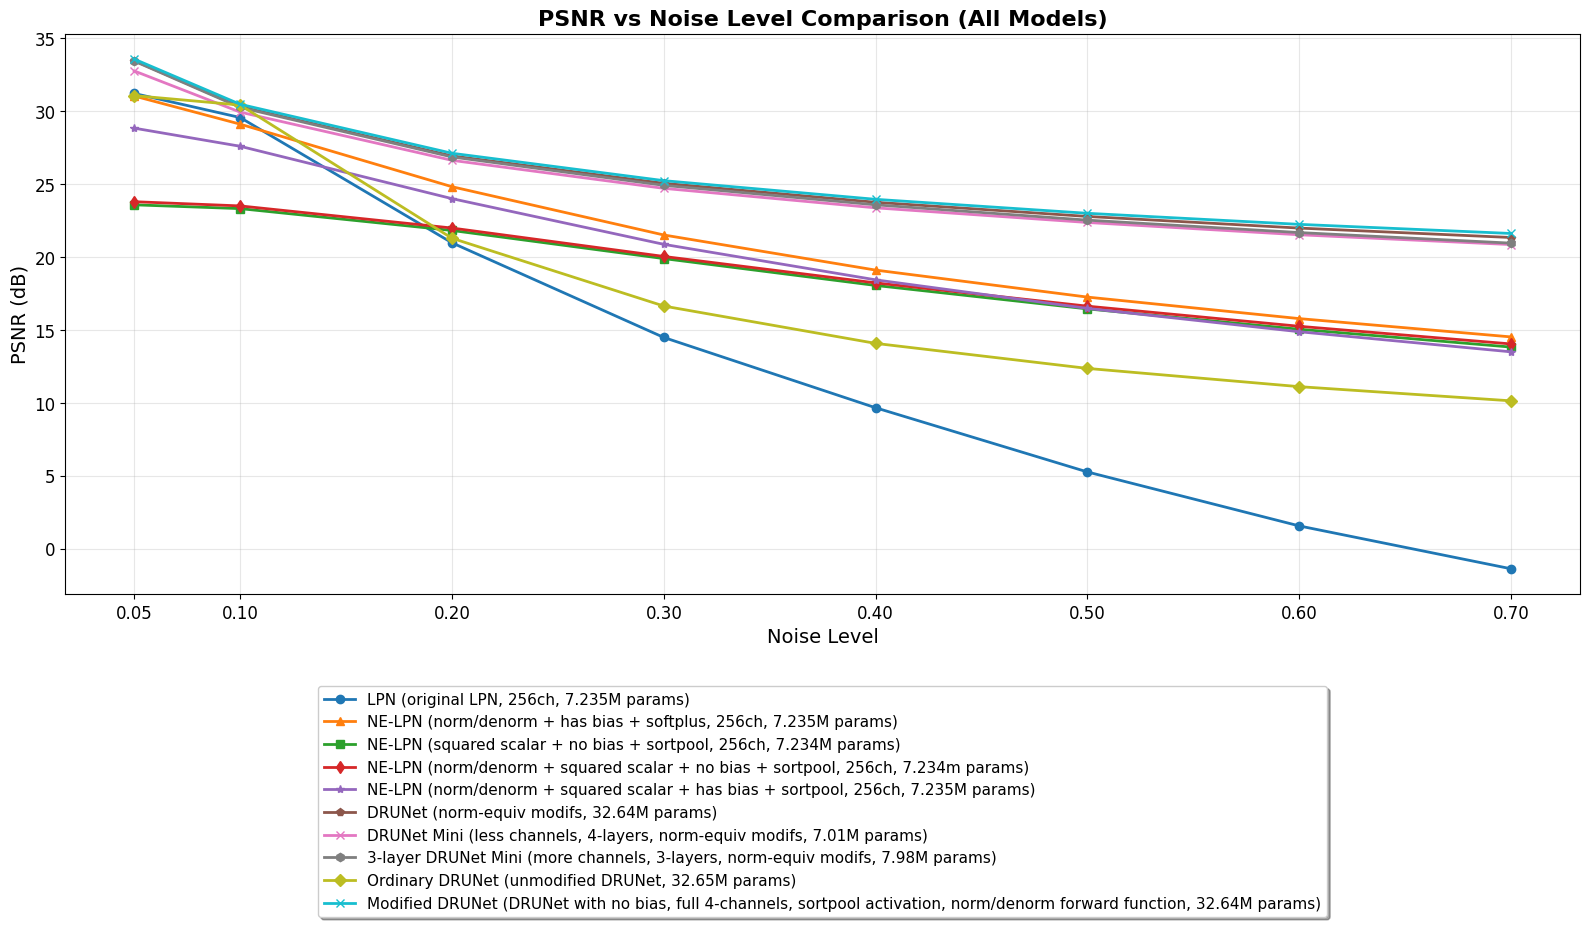

In [36]:
plt.figure(figsize=(16, 8))  # Much wider figure

# Plotting lines with better styling

plt.plot(noise_levels, lpn_psnr, label='LPN (original LPN, 256ch, 7.235M params)', linewidth=2, marker='o')
plt.plot(noise_levels, ne_by_forward_psnr, label='NE-LPN (norm/denorm + has bias + softplus, 256ch, 7.235M params)', linewidth=2, marker='^')
plt.plot(noise_levels, ne_lpn_psnr, label='NE-LPN (squared scalar + no bias + sortpool, 256ch, 7.234M params)', linewidth=2, marker='s')
plt.plot(noise_levels, ne_norm_and_scaled_psnr, label='NE-LPN (norm/denorm + squared scalar + no bias + sortpool, 256ch, 7.234m params)', linewidth=2, marker='d')
plt.plot(noise_levels, ne_norm_and_scaled_wbias_psnr, label='NE-LPN (norm/denorm + squared scalar + has bias + sortpool, 256ch, 7.235M params)', linewidth=2, marker='*')
plt.plot(noise_levels, drunet_psnr, label='DRUNet (norm-equiv modifs, 32.64M params)', linewidth=2, marker='p')
plt.plot(noise_levels, drunet_mini_psnr, label='DRUNet Mini (less channels, 4-layers, norm-equiv modifs, 7.01M params)', linewidth=2, marker='x')
plt.plot(noise_levels, less_drunet_mini_psnr, label='3-layer DRUNet Mini (more channels, 3-layers, norm-equiv modifs, 7.98M params)', linewidth=2, marker='h')
plt.plot(noise_levels, ordinary_drunet_psnr, label='Ordinary DRUNet (unmodified DRUNet, 32.65M params)', linewidth=2, marker='D')
plt.plot(noise_levels, modified_drunet_psnr, label='Modified DRUNet (DRUNet with no bias, full 4-channels, sortpool activation, norm/denorm forward function, 32.64M params)', linewidth=2, marker='x')

plt.xlabel('Noise Level', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.title('PSNR vs Noise Level Comparison (All Models)', fontsize=16, fontweight='bold')
plt.xticks(noise_levels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

# Legend below the plot with single column for readability
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=1, fontsize=11, frameon=True, fancybox=True, shadow=True)

# Adjust layout to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for legend

plt.show()

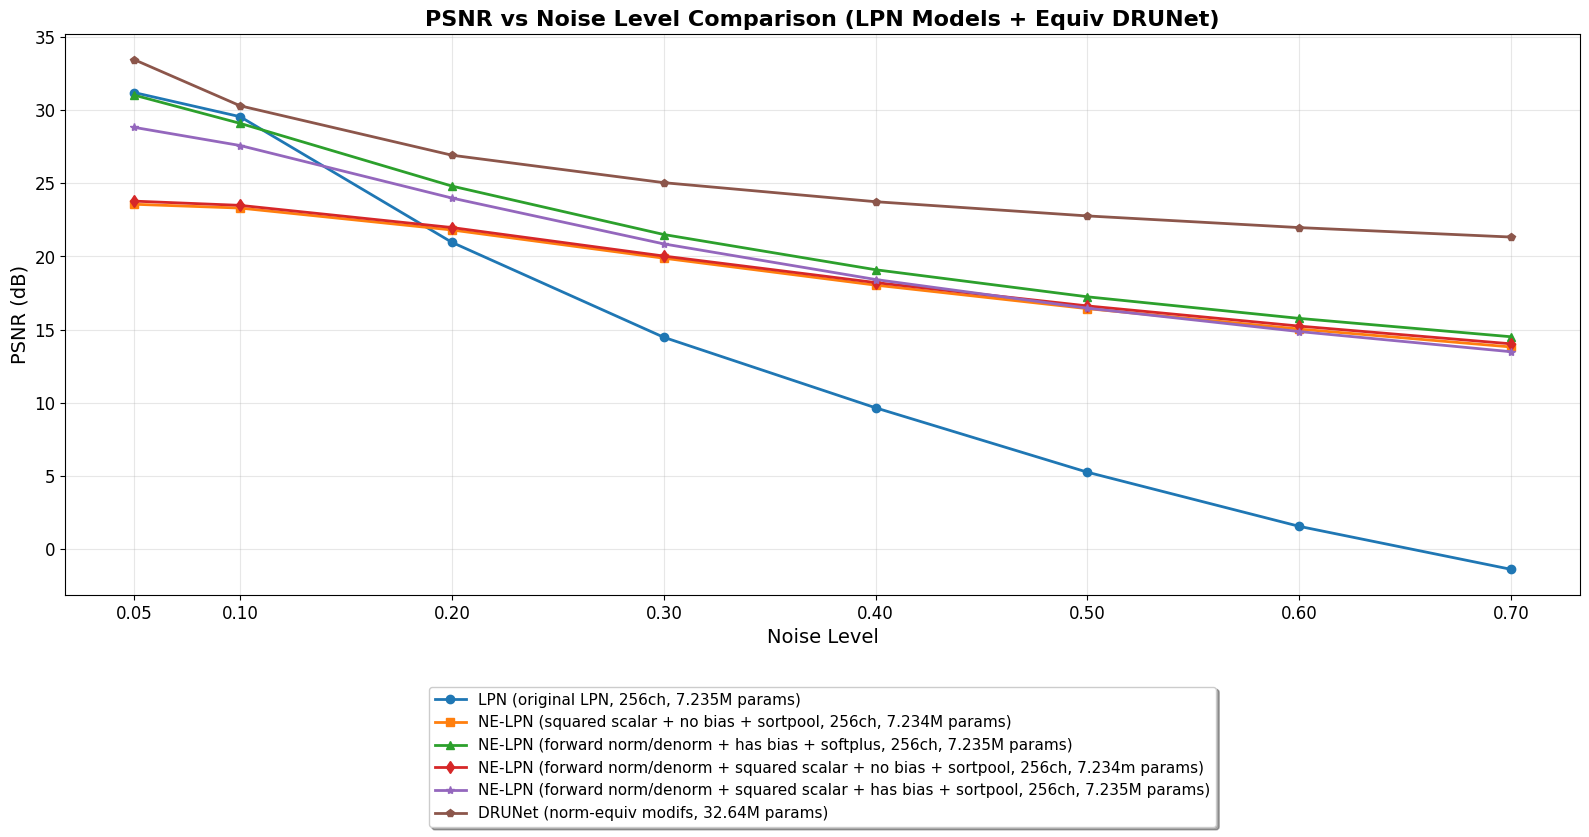

In [37]:
plt.figure(figsize=(16, 8))  # Much wider figure

# Plotting lines with better styling

plt.plot(noise_levels, lpn_psnr, label='LPN (original LPN, 256ch, 7.235M params)', linewidth=2, marker='o')
plt.plot(noise_levels, ne_lpn_psnr, label='NE-LPN (squared scalar + no bias + sortpool, 256ch, 7.234M params)', linewidth=2, marker='s')
plt.plot(noise_levels, ne_by_forward_psnr, label='NE-LPN (forward norm/denorm + has bias + softplus, 256ch, 7.235M params)', linewidth=2, marker='^')
plt.plot(noise_levels, ne_norm_and_scaled_psnr, label='NE-LPN (forward norm/denorm + squared scalar + no bias + sortpool, 256ch, 7.234m params)', linewidth=2, marker='d')
plt.plot(noise_levels, ne_norm_and_scaled_wbias_psnr, label='NE-LPN (forward norm/denorm + squared scalar + has bias + sortpool, 256ch, 7.235M params)', linewidth=2, marker='*')
plt.plot(noise_levels, drunet_psnr, label='DRUNet (norm-equiv modifs, 32.64M params)', linewidth=2, marker='p')

plt.xlabel('Noise Level', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.title('PSNR vs Noise Level Comparison (LPN Models + Equiv DRUNet)', fontsize=16, fontweight='bold')
plt.xticks(noise_levels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

# Legend below the plot with single column for readability
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=1, fontsize=11, frameon=True, fancybox=True, shadow=True)

# Adjust layout to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for legend

plt.show()

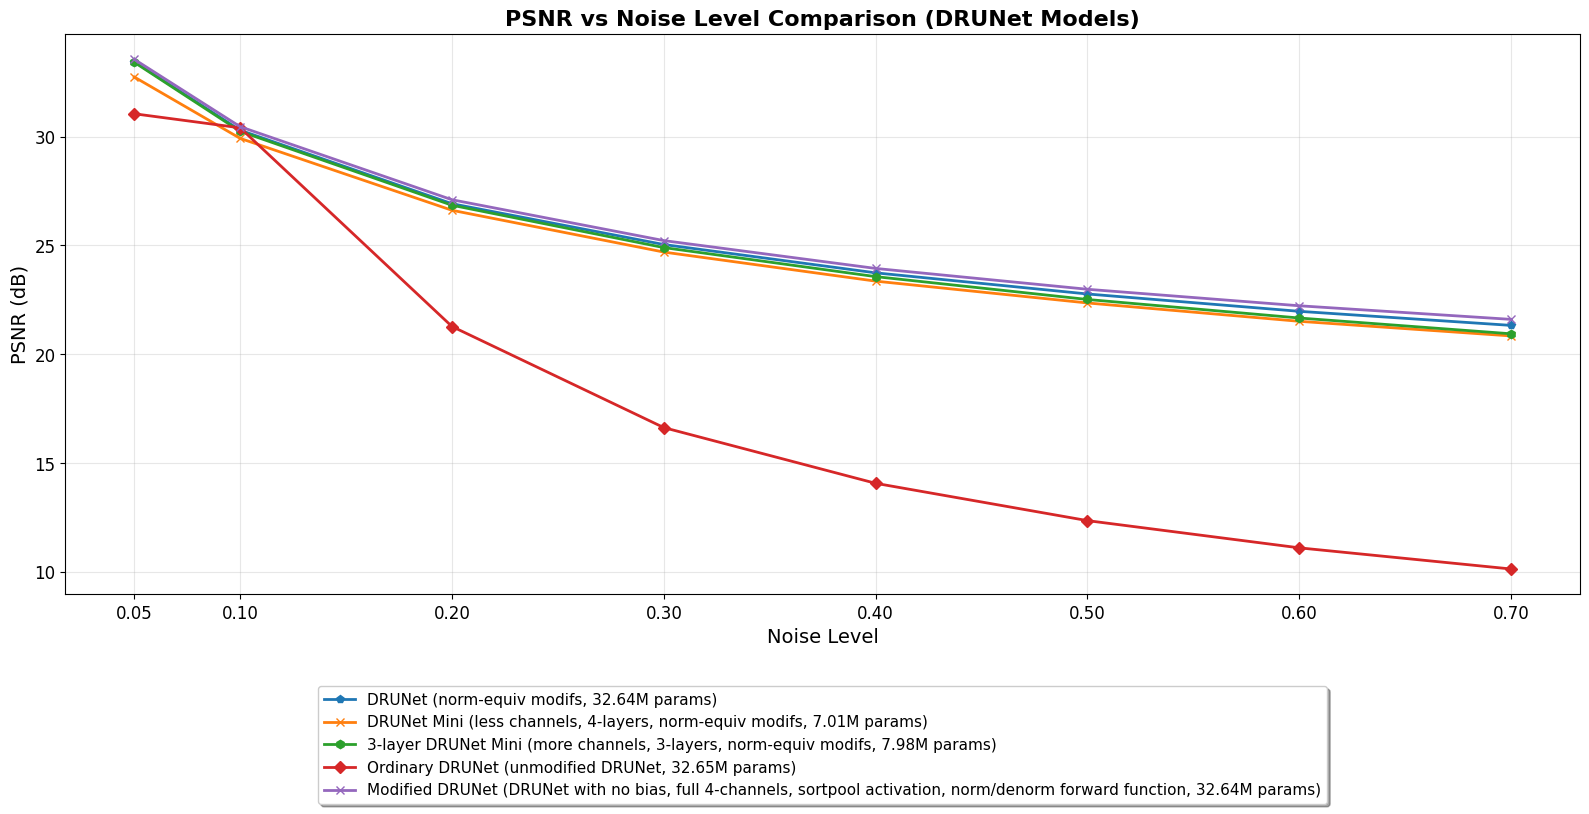

In [38]:
plt.figure(figsize=(16, 8))  # Much wider figure
plt.plot(noise_levels, drunet_psnr, label='DRUNet (norm-equiv modifs, 32.64M params)', linewidth=2, marker='p')
plt.plot(noise_levels, drunet_mini_psnr, label='DRUNet Mini (less channels, 4-layers, norm-equiv modifs, 7.01M params)', linewidth=2, marker='x')
plt.plot(noise_levels, less_drunet_mini_psnr, label='3-layer DRUNet Mini (more channels, 3-layers, norm-equiv modifs, 7.98M params)', linewidth=2, marker='h')
plt.plot(noise_levels, ordinary_drunet_psnr, label='Ordinary DRUNet (unmodified DRUNet, 32.65M params)', linewidth=2, marker='D')
plt.plot(noise_levels, modified_drunet_psnr, label='Modified DRUNet (DRUNet with no bias, full 4-channels, sortpool activation, norm/denorm forward function, 32.64M params)', linewidth=2, marker='x')

plt.xlabel('Noise Level', fontsize=14)
plt.ylabel('PSNR (dB)', fontsize=14)
plt.title('PSNR vs Noise Level Comparison (DRUNet Models)', fontsize=16, fontweight='bold')
plt.xticks(noise_levels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

# Legend below the plot with single column for readability
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=1, fontsize=11, frameon=True, fancybox=True, shadow=True)

# Adjust layout to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for legend

plt.show()